In [34]:
import numpy as np

In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.metrics import ( accuracy_score, confusion_matrix, classification_report )

In [ ]:
df = pd.read_csv("Social_Network_Ads.csv")

In [ ]:
print("FIRST 5 ROWS:")

FIRST 5 ROWS:


In [ ]:
print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [ ]:
print("\nDATASET SHAPE:")
print(df.shape)


DATASET SHAPE:
(400, 5)


In [ ]:
print("\nCOLUMN NAMES:")
print(df.columns)


COLUMN NAMES:
Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')


In [ ]:
print("\nDATA TYPES:")
print(df.info())


DATA TYPES:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None


In [ ]:
print("\nSTATISTICAL SUMMARY:")
print(df.describe())


STATISTICAL SUMMARY:
            User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.000000
mean   1.569154e+07   37.655000     69742.500000    0.357500
std    7.165832e+04   10.482877     34096.960282    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   29.750000     43000.000000    0.000000
50%    1.569434e+07   37.000000     70000.000000    0.000000
75%    1.575036e+07   46.000000     88000.000000    1.000000
max    1.581524e+07   60.000000    150000.000000    1.000000


In [ ]:
print("\nMISSING VALUES:")
print(df.isnull().sum())


MISSING VALUES:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [ ]:
df.drop('User ID', axis=1, inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()

In [ ]:
df['Gender'] = le.fit_transform(df['Gender'])

In [ ]:
print("\nAFTER ENCODING:")
print(df.head())


AFTER ENCODING:
   Gender  Age  EstimatedSalary  Purchased
0       1   19            19000          0
1       1   35            20000          0
2       0   26            43000          0
3       0   27            57000          0
4       1   19            76000          0


In [ ]:
X = df[['Age', 'EstimatedSalary']]

In [ ]:
y = df['Purchased']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=42 )

In [ ]:
print("\nTRAINING DATA SIZE:")
print(X_train.shape)


TRAINING DATA SIZE:
(300, 2)


In [ ]:
print("\nTESTING DATA SIZE:")
print(X_test.shape)


TESTING DATA SIZE:
(100, 2)


In [ ]:
sc = StandardScaler()

In [ ]:
X_train = sc.fit_transform(X_train)

In [ ]:
X_test = sc.transform(X_test)

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
print("\nMODEL TRAINED SUCCESSFULLY")


MODEL TRAINED SUCCESSFULLY


In [35]:
y_pred = model.predict(X_test)

In [36]:
print("\nPREDICTIONS:")
print(y_pred)


PREDICTIONS:
[0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 0
 0 0 1 1 0 0 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 0 1 0 1 0]


In [37]:
accuracy = accuracy_score(y_test, y_pred)

In [38]:
print("\nACCURACY:")
print(accuracy)


ACCURACY:
0.86


In [39]:
cm = confusion_matrix(y_test, y_pred)

In [40]:
print("\nCONFUSION MATRIX:")
print(cm)


CONFUSION MATRIX:
[[61  2]
 [12 25]]


In [41]:
print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.84      0.97      0.90        63
           1       0.93      0.68      0.78        37

    accuracy                           0.86       100
   macro avg       0.88      0.82      0.84       100
weighted avg       0.87      0.86      0.85       100



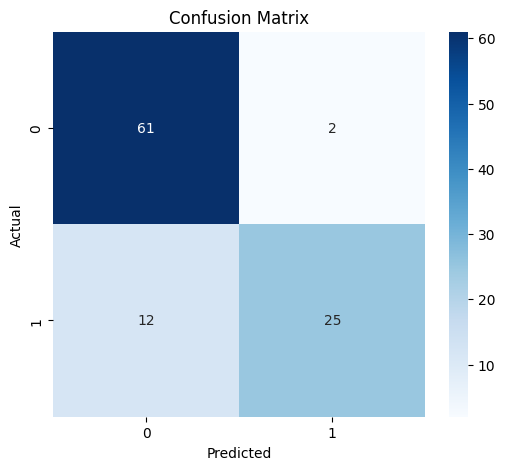

In [48]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

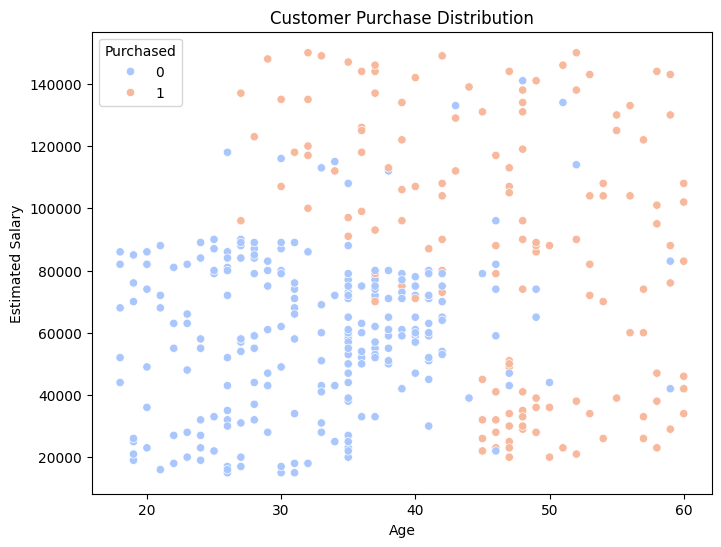

In [49]:
plt.figure(figsize=(8,6))
sns.scatterplot( x=df['Age'], y=df['EstimatedSalary'], hue=df['Purchased'], palette='coolwarm' )
plt.title("Customer Purchase Distribution")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.show()

In [52]:
new_customer = pd.DataFrame(
    [[40, 90000]],
    columns=['Age', 'EstimatedSalary']
)

In [53]:
new_customer_scaled = sc.transform(new_customer)

In [54]:
prediction = model.predict(new_customer_scaled)

In [57]:
probability = model.predict_proba(new_customer_scaled)

In [60]:
print("\nCUSTOMER PREDICTION:")

if prediction[0] == 1:
    print("Customer WILL BUY the product")
else:
    print("Customer WILL NOT BUY the product")

print("\nPROBABILITIES:")
print(probability)


CUSTOMER PREDICTION:
Customer WILL BUY the product

PROBABILITIES:
[[0.49224829 0.50775171]]


In [61]:
print("\nMODEL WEIGHTS:")
print(model.coef_)
print("\nMODEL BIAS:")
print(model.intercept_)


MODEL WEIGHTS:
[[1.92307917 1.07843614]]

MODEL BIAS:
[-1.03148422]
